# Simple Regression Exercise

Study based on the book "Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow" by Aurélien Géron.

This notebook explores fundamental concepts of linear regression using Python tools such as NumPy, Matplotlib, and Scikit-Learn.

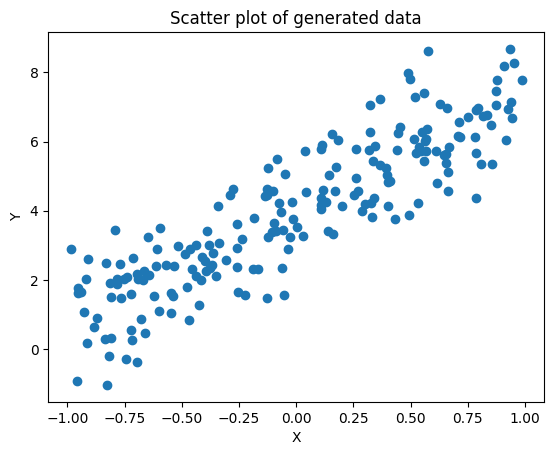

In [1]:
import numpy as np

rng = np.random.default_rng(42)
m = 200 # Number of samplesç
X = 2 * rng.random((m, 1)) - 1 # Uniformly distributed in [-1, 1]
Y = 4 + 3 *X + rng.standard_normal((m, 1))

# Visualize the data
import matplotlib.pyplot as plt
plt.scatter(X, Y)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Scatter plot of generated data")
plt.show()

In [2]:
from sklearn.preprocessing import StandardScaler, add_dummy_feature
X_b = add_dummy_feature(X) # Add bias term (intercept)
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ Y
print("Best parameters (theta):", theta_best)
# Predict using the model

Best parameters (theta): [[4.02044597]
 [3.32960458]]


In [3]:
X_new = np.array([[0], [2]])
X_new_b = add_dummy_feature(X_new)
Y_predict = X_new_b @ theta_best
print("Predictions for new data points:", Y_predict)

Predictions for new data points: [[ 4.02044597]
 [10.67965513]]


we can see that the model in case '0' only sum the bias term.
in the case '2' the model sum the bias term plus two times the weight parameter.

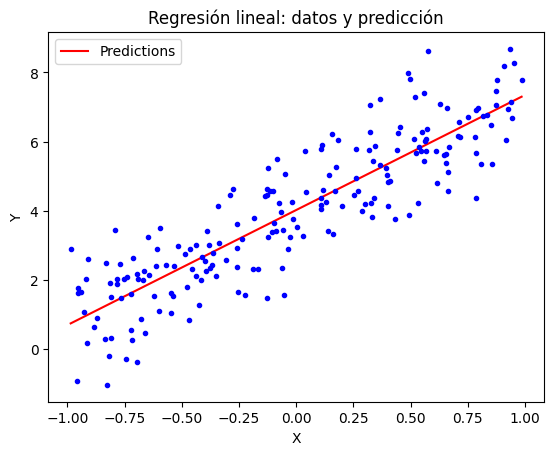

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Para ver la línea roja completa, extendemos el rango de X_new
X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
X_range_b = add_dummy_feature(X_range)
Y_range_predict = X_range_b @ theta_best

plt.plot(X_range, Y_range_predict, "r-", label="Predictions")
plt.plot(X, Y, "b.")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Regresión lineal: datos y predicción")
plt.legend()
plt.show()

In [27]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X, Y)
print("Model parameters from scikit-learn:")
print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_)

Model parameters from scikit-learn:
Intercept: [4.02044597]
Coefficient: [[3.32960458]]


we obtain the same parameters as before using scikit-learn's LinearRegression model

Important using the pseudoinverse because it is more stable numerically. it can calculate the inverse of non-square matrices and is less sensitive to numerical errors.
singular value decomposition (SVD) is used to compute the pseudoinverse.

But when we have a bigger dataset with more features, using the pseudoinverse method becomes computationally expensive. In such cases, iterative optimization algorithms like Gradient Descent are preferred for training linear regression models efficiently.

## Gradient Descent

is a generic optimization algorithm capable of finding optimal solutions to a wide range of problems. It is particularly useful for training machine learning models, including linear regression.

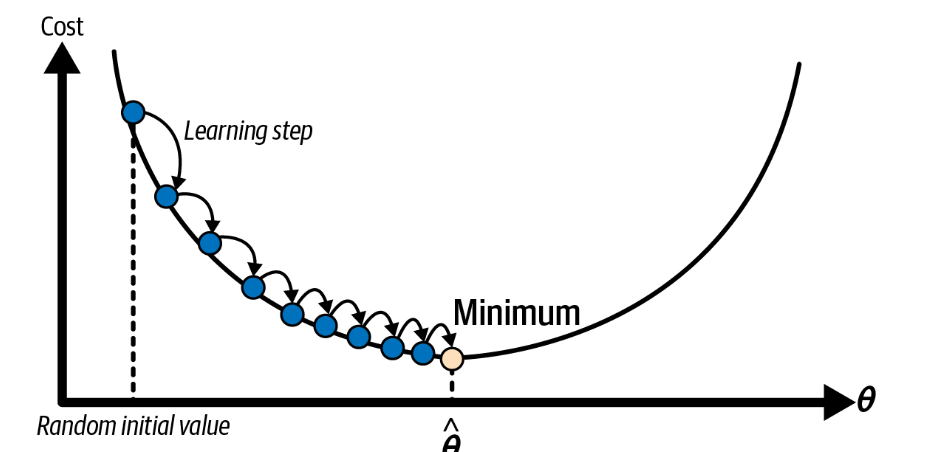

Multiple strategies for reading a dataset in batches:
- **Stochatic Gradient Descent (SGD)**: Take a single random sample from the dataset to compute the gradient and update the model parameters. 
- **Mini-batch Gradient Descent**: Use a small random subset (mini-batch) of the dataset to compute the gradient and update the model parameters. 
- **Batch Gradient Descent**: Use the entire dataset to compute the gradient and update the model parameters.

In [ ]:
# Example
# For Step using 0 - alpha * MSE(O)
eta = 0.1 # Learning rate
n_epochs = 1
m = len(X_b)
print("Parameters before Gradient Descent:", theta_best)

rng = np.random.default_rng(42) # Initialize random number generator
theta = rng.standard_normal((2,1)) # Random initialization of parameters

for epoch in range(n_epochs):
  gradient = 2 / m * X_b.T @ (X_b @ theta - Y)
  theta = theta - eta * gradient
  theta
print("Parameters after Gradient Descent:", theta)

In [ ]:
n_epoch = 50
t0, t1 = 5, 50  # Learning schedule hyperparameters

def learning_schedule(t):
  return t0 / (t + t1)

rng = np.random.default_rng(42) # Initialize random number generator
theta = rng.standard_normal((2, 1))
m = len(X_b)
for epoch in range(n_epoch):
  for iteration in range(m):
    random_index  = rng.integers(m)
    xi = X_b[random_index : random_index + 1]
    yi = Y[random_index : random_index + 1]
    gradient = 2 * xi.T @ (xi @ theta - yi)
    eta = learning_schedule(epoch * m + iteration)
    theta = theta - eta * gradient

### Using SGD with sklearn's SGDRegressor
optimizer with Mean Squared Error (MSE) loss function

In [ ]:
from sklearn.linear_model import SGDRegressor
sgd_reg = SGDRegressor(max_iter=1000, tol=1e-5, penalty=None, eta0=0.01,
                       n_iter_no_change=100, random_state=42)
sgd_reg.fit(X, Y.ravel())
print("Model parameters from SGDRegressor:")